In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 3.2)
mpl.rcParams['agg.path.chunksize'] = 10000

In [2]:
import numpy as np
import scipy.special as sp
from  scipy.constants import c
import matplotlib.pyplot as plt
#!pip install OptiCommPy
#from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm
#from optic.models.devices import mzm, photodiode

## Dispersao e Perda.
---

## Sumário
---
- [Pulsos](#pulsos)
- [Equação de Propagação e Dispersão Cromática](#equação_de_propagação_e_dispersão_cromática)
- [Pulso Gaussiano "chirpado"](#pulso_gaussiano_"chirpado")

### Pulsos
---

#### Pulso Gausiano

Pulso ideal em teoria e prática, O pulso Gaussiano é amplamente utilizado por apresentar propriedades ideais: Simetria temporal e espectral, Transformada de Fourier também Gaussiana, Menor produto tempo-largura. O código abixo serve para estudar como a largura temporal $T_0$ de um pulso Gaussiano afeta sua largura espectral, conforme o teorema da dualidade tempo-frequência. Ele também mostra o excelente ajuste entre o modelo analítico e a implementação numérica via FFT. O Pulso Gaussiano pode ser expresso por:

$$
A(0,t) = A_0e^{-\frac{1}{2}(\frac{t}{T_o})^2}
$$



In [4]:
def GaussPulse(a0, t0, t):
  return a0*np.exp(-0.5*(t/t0)**2)

T0 = np.array([0.2, 0.07])                   # Parâmetro meia largura
A0 = 1                                      # Amplitude do pulso
fs = 100                                    # Taxa de amostragem
NFFT = 1024                                 # Número de pontos da FFT
t  = np.arange(-0.5,0.5,1/fs)
f = fs/NFFT * np.arange(-NFFT/2,NFFT/2)
L = len(t)

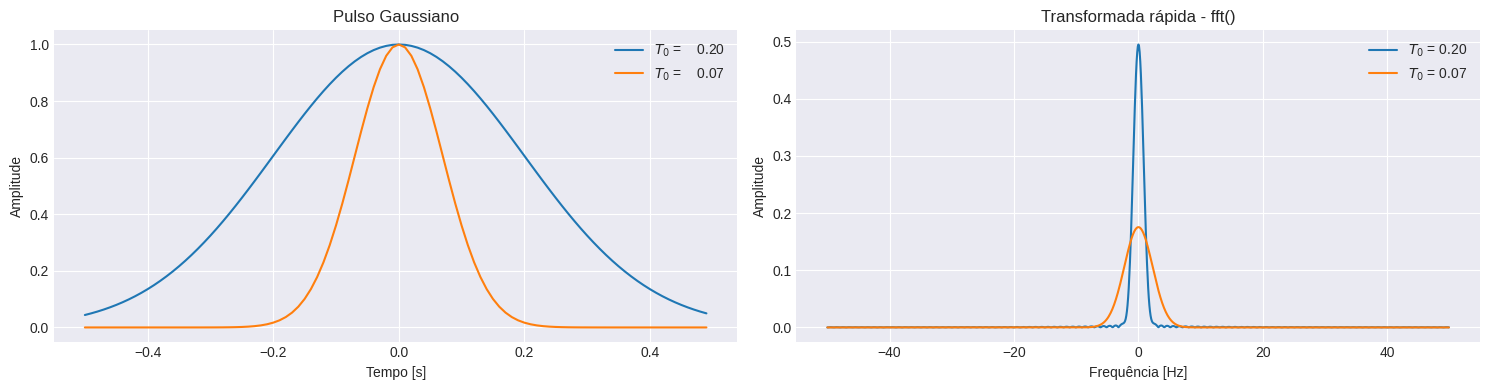

In [5]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axs = plt.subplots(1, 2, figsize=(15,4))
for i in range(len(T0)):
  x   = GaussPulse(A0, T0[i], t)
  axs[0].plot(t, x, label = r"$T_0$ = %7.2f" % (T0[i]))
  axs[0].set_xlabel("Tempo [s]")
  axs[0].set_ylabel("Amplitude")
  axs[0].legend()
  axs[0].set_title("Pulso Gaussiano")

  Xf  = np.fft.fftshift(np.fft.fft(x, NFFT))
  axs[1].plot(f, abs(Xf)/L, label = r"$T_0$ = %3.2f" % (T0[i]))
  axs[1].set_xlabel("Frequência [Hz]")
  axs[1].set_ylabel("Amplitude")
  axs[1].legend()
  axs[1].set_title("Transformada rápida - fft()")

plt.tight_layout()

#### Pulso super Gaussiano

O pulso Super Gaussiano é uma generalização da Gaussiana clássica. Sua expressão é, em que $m$ corresponde ao coeficiente de formato de borda. Para $m = 1$, é obtido o pulso Gaussiano descrito anteriormente. Para elevados valores de $m$ o pulso apresenta formato próximo ao retangular. O Pulso Super Gaussiano pode ser expresso por:

$$
A(0,t) = A_0e^{-\frac{1}{2}(\frac{t}{T_o})^{2m}}
$$

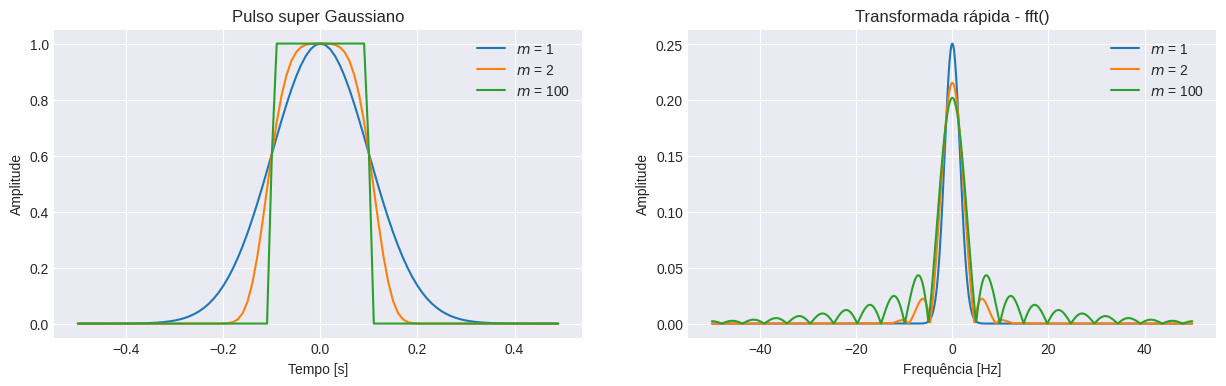

In [6]:
def SuperGaussPulse(a0, t0, t, m):
  return a0*np.exp(-0.5*(t/t0)**(2*m))

T0 = 0.1
m  = np.array([1, 2, 100])

fig, axs = plt.subplots(1,2, figsize=(15,4))
for i in range(len(m)):
  x   = SuperGaussPulse(A0, T0, t, m[i])
  axs[0].plot(t, x, label = r"$m$ = %d" % (m[i]))
  axs[0].set_xlabel("Tempo [s]")
  axs[0].set_ylabel("Amplitude")
  axs[0].set_title("Pulso super Gaussiano")
  axs[0].legend()
  Xf  = np.fft.fftshift(np.fft.fft(x, NFFT))
  axs[1].plot(f, abs(Xf)/L, label = r"$m$ = %d" % (m[i]))
  axs[1].set_xlabel("Frequência [Hz]")
  axs[1].set_ylabel("Amplitude")
  axs[1].set_title("Transformada rápida - fft()")
  axs[1].legend()

#### Equação de Propagação e Dispersão Cromática
---

Quando um pulso de luz é lançado em uma fibra óptica, ele pode sofrer alargamento temporal devido à dispersão cromática(ou GVD — Group Velocity Dispersion). Isso acontece porque diferentes componentes espectrais (frequências) do pulso se propagam a velocidades ligeiramente diferentes.

No domínio da frequência, a solução da equação de propagação linear com GVD é dada por:

$$H(f) = H_0e^{j\frac{β_2}{2}zω^2},\ β_2 \text{ é o coeficiente de dispersão}$$

In [7]:
def FGaussPulse(a0, t0, freq):  # Transformada de Fourier do pulso Gaussiano (analítica)
  return a0*t0*np.sqrt(2*np.pi)*np.exp(-0.5*(2*np.pi*freq*t0)**2)

fs = 256                        # Taxa de amostragem
NFFT = 256
t  = np.arange(-0.5,0.5,1/fs)
L = len(t)
f = fs/NFFT * np.arange(-NFFT/2,NFFT/2)
beta2 = 20e-6                   # parâmetro GVD
z = 250                         # distância de propagação
T0 = 0.05                       # Parâmetro meia largura
A0 = 1                          # Amplitude do pulso

#Função de dispersão do sinal
H  = np.exp(1j*0.5*beta2*z*(2*np.pi*f)**2)

x  = GaussPulse(A0, T0, t)
X  = FGaussPulse(A0, T0, f)
XH = X*H
xh  = np.fft.ifftshift(np.fft.ifft(XH))
xhA = T0/np.sqrt(T0**2-1j*beta2*z) * np.exp(-(t**2)/(2*(T0**2-1j*beta2*z)))

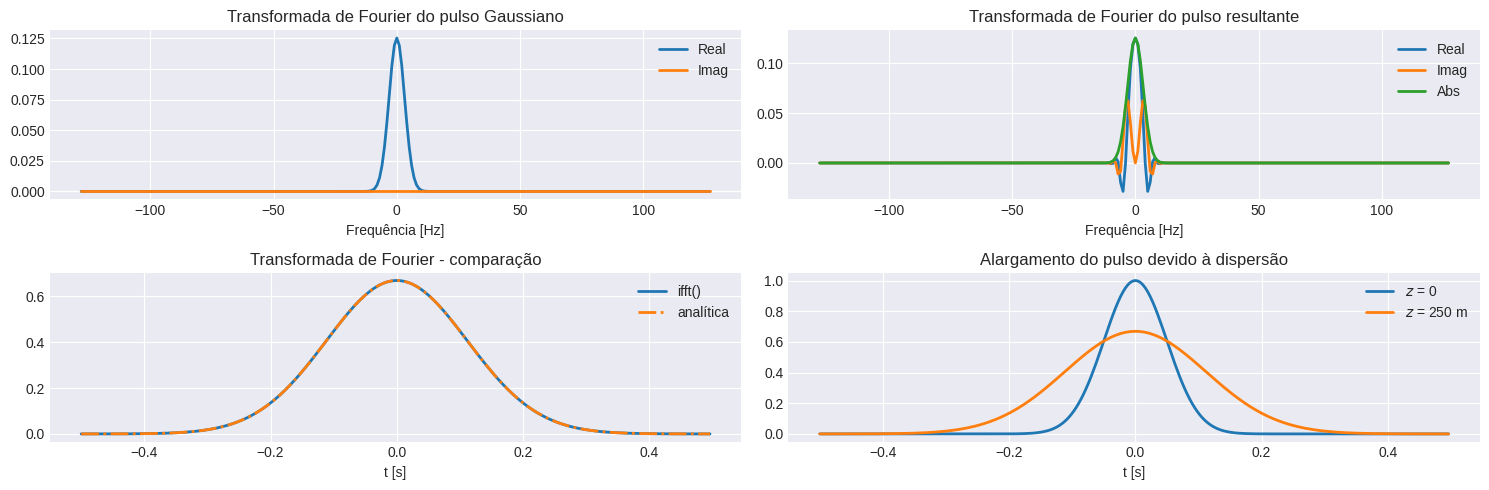

In [8]:
fig, axs = plt.subplots(2,2, figsize=(15,5))
axs[0,0].plot(f, X.real, label = 'Real', linewidth = 2)
axs[0,0].plot(f, X.imag, label = 'Imag', linewidth = 2)
axs[0,0].set_xlabel('Frequência [Hz]')
axs[0,0].set_title('Transformada de Fourier do pulso Gaussiano')
axs[0,0].legend()

axs[0,1].plot(f, XH.real, label = 'Real', linewidth = 2)
axs[0,1].plot(f, XH.imag, label = 'Imag', linewidth = 2)
axs[0,1].plot(f, np.abs(XH), label = 'Abs', linewidth = 2)
axs[0,1].set_xlabel('Frequência [Hz]')
axs[0,1].set_title('Transformada de Fourier do pulso resultante')
axs[0,1].legend()

axs[1,0].plot(t, np.abs(xh*L), label = 'ifft()', linewidth = 2)
axs[1,0].plot(t, np.abs(xhA), '-.', label = 'analítica', linewidth = 2)
axs[1,0].set_xlabel('t [s]')
axs[1,0].set_title('Transformada de Fourier - comparação')
axs[1,0].legend()

axs[1,1].plot(t, x, label = r'$z$ = 0', linewidth = 2)
axs[1,1].plot(t, np.abs(xhA), label = r'$z$ = %d m' %(z), linewidth = 2)
axs[1,1].set_xlabel('t [s]')
axs[1,1].set_title('Alargamento do pulso devido à dispersão')
axs[1,1].legend()

plt.tight_layout()

Quando a frequência instantânea de um pulso varia ao longo do tempo, dizemos que ele possui chirp (ou gorjeio em português), o chirp define o perfil de variação da frequência ao longo do tempoA amplitude desse sinal é:

$$
A(0,t) = A_0e^{-\frac{1 + jC}{2}(\frac{t}{T_o})^2}
$$

In [12]:
def CGaussPulse(a0, t0, t, c):      # Expressão do pulso Gaussiano
  return a0*np.exp(-0.5*(1+1j*c)*(t/t0)**2)
def CFGaussPulse(a0, t0, freq, c):  # Transformada de Fourier do pulso Gaussiano (analítica)
  return a0*np.sqrt((2*np.pi*t0**2)/(1+1j*C))*np.exp(-0.5*((2*np.pi*freq*t0)**2)/(1+1j*C))

T0 = 0.05                       # Parâmetro meia largura @1/e
A0 = 1                          # Amplitude do pulso
fs = 256                        # Taxa de amostragem
NFFT = 256                      # Número de pontos da transformada
beta2 = 20e-6                   # parâmetro GVD
z = 250                         # distância de propagação
t  = np.arange(-0.5,0.5,1/fs)   # Duração da janela do pulso
L = len(t)                      # Comprimento da janela temporal
f = fs/NFFT * np.arange(-NFFT/2,NFFT/2)
C = 2

#Função de dispersão do sinal
H  = np.exp(1j*0.5*beta2*z*(2*np.pi*f)**2)


xC  = CGaussPulse(A0, T0, t, C)

XC  = CFGaussPulse(A0, T0, f, C)
XHC = XC*H
xhC  = np.fft.ifftshift(np.fft.ifft(XHC))
Q = 1 + (C-1j)*beta2*z/T0**2
xhAC = A0/np.sqrt(Q) * np.exp(-0.5*((1+1j*C)/Q)*(t/T0)**2)

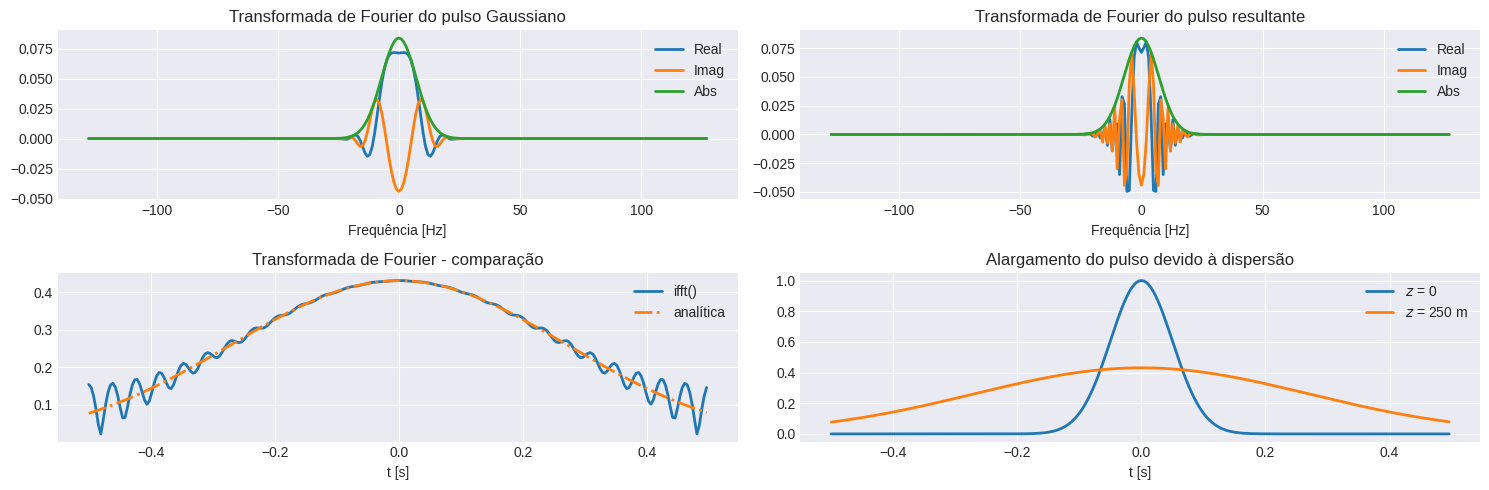

In [16]:
fig, axs = plt.subplots(2,2, figsize=(15,5))
axs[0,0].plot(f, XC.real, label = "Real", linewidth = 2)
axs[0,0].plot(f, XC.imag, label = "Imag", linewidth = 2)
axs[0,0].plot(f, abs(XC), label = "Abs", linewidth = 2)
axs[0,0].set_xlabel("Frequência [Hz]")
axs[0,0].set_title("Transformada de Fourier do pulso Gaussiano")
axs[0,0].legend()

axs[0,1].plot(f, XHC.real, label = "Real", linewidth = 2)
axs[0,1].plot(f, XHC.imag, label = "Imag", linewidth = 2)
axs[0,1].plot(f, np.abs(XHC), label = "Abs", linewidth = 2)
axs[0,1].set_xlabel("Frequência [Hz]")
axs[0,1].set_title("Transformada de Fourier do pulso resultante")
axs[0,1].legend()

axs[1,0].plot(t, abs(xhC*L), label = "ifft()", linewidth = 2)
axs[1,0].plot(t, abs(xhAC), "-.", label = "analítica", linewidth = 2)
axs[1,0].set_xlabel("t [s]")
axs[1,0].set_title("Transformada de Fourier - comparação")
axs[1,0].legend()

axs[1,1].plot(t, abs(xC), label = r"$z$ = 0", linewidth = 2)
axs[1,1].plot(t, abs(xhAC), label = r"$z$ = %d m" %(z), linewidth = 2)
axs[1,1].set_xlabel("t [s]")
axs[1,1].set_title("Alargamento do pulso devido à dispersão")
axs[1,1].legend()

plt.tight_layout()